In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("typing_speed_train.csv")
df.head()

,date,days_ago,wpm,acc,rawWpm,consistency
0,2023-01-15,999,76.89,100.00,76.89,64.65
1,2023-01-16,998,81.67,100.00,81.67,79.00
2,2023-01-17,997,66.03,95.08,66.03,65.34
3,2023-01-18,996,93.18,100.00,93.18,75.54
4,2023-01-19,995,94.22,97.92,94.22,65.40


In [4]:
df = df.apply(pd.to_numeric, errors='coerce')

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         0 non-null      float64
 1   days_ago     999 non-null    int64  
 2   wpm          999 non-null    float64
 3   acc          999 non-null    float64
 4   rawWpm       999 non-null    float64
 5   consistency  999 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 47.0 KB


,date,days_ago,wpm,acc,rawWpm,consistency
count,0.0,999.000000,999.000000,999.000000,999.000000,999.000000
mean,NaN,500.000000,85.748058,96.192032,89.908298,67.370070
std,NaN,288.530761,17.857199,4.044028,19.673983,12.349825
min,NaN,1.000000,23.440000,76.190000,26.790000,0.760000
25%,NaN,250.500000,72.525000,94.000000,74.415000,59.020000
50%,NaN,500.000000,83.540000,96.720000,87.050000,66.570000
75%,NaN,749.500000,98.870000,100.000000,105.610000,75.940000
max,NaN,999.000000,150.680000,100.000000,150.680000,95.860000


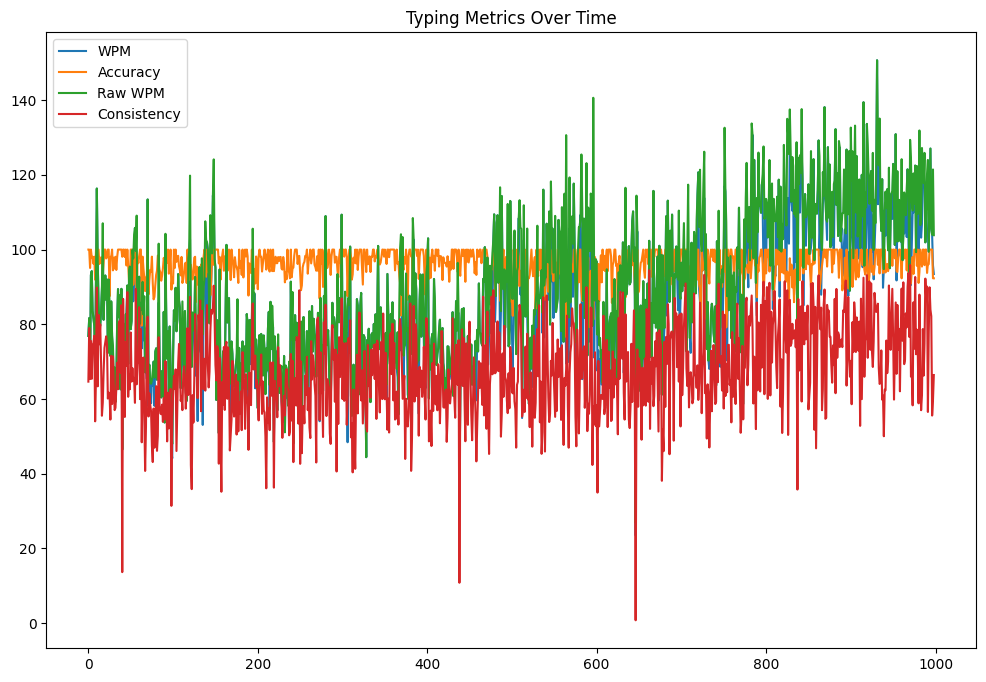

In [6]:
plt.figure(figsize=(12, 8))

plt.plot(df['wpm'], label='WPM')
plt.plot(df['acc'], label='Accuracy')
plt.plot(df['rawWpm'], label='Raw WPM')
plt.plot(df['consistency'], label='Consistency')

plt.legend()
plt.title("Typing Metrics Over Time")
plt.show()

In [25]:
df = df[['wpm', 'acc', 'rawWpm', 'consistency']]

In [26]:
train = df.iloc[:800]
val = df.iloc[800:]

In [27]:
print(len(train), len(val))

800 199


## Baseline Model

Starting with simple baseline approaches:

1. Last Value Predictor — assumes the next value is equal to the most recent observation  
2. Moving Average — averages recent values to smooth noise  

These models are simple but provide a strong reference point for evaluating more complex models.

In [28]:
# Last value predictor
def last_value_predict(train, val):
    last_row = train.iloc[-1].values.reshape(1, -1)
    preds = np.repeat(last_row, len(val), axis=0)
    return preds


# Moving average predictor
def moving_average_predict(train, val, window=5):
    preds = []
    history = train.copy()

    for _ in range(len(val)):
        avg = history.tail(window).mean(numeric_only=True).values
        preds.append(avg)

        # append prediction to history
        history.loc[len(history)] = avg

    return np.array(preds)


# Generate predictions
last_preds = last_value_predict(train, val)
ma_preds = moving_average_predict(train, val, window=5)

print("last_preds shape:", last_preds.shape)
print("ma_preds shape:", ma_preds.shape)
print("val shape:", val.shape)

last_preds shape: (199, 4)
ma_preds shape: (199, 4)
val shape: (199, 4)


In [29]:
from sklearn.metrics import mean_absolute_error

def evaluate(preds, val):
    preds = np.array(preds)

    # safety check
    assert preds.shape[0] == len(val), "Prediction length mismatch"
    assert preds.shape[1] == len(val.columns), "Feature mismatch"

    scores = {}

    for i, col in enumerate(val.columns):
        y_true = val[col].values.astype(float)
        y_pred = preds[:, i].astype(float)

        scores[col] = mean_absolute_error(y_true, y_pred)

    return scores

In [30]:
print("Last Value:", evaluate(last_preds, val))
print("Moving Avg:", evaluate(ma_preds, val))

Last Value: {'wpm': 9.052010050251258, 'acc': 3.5453768844221103, 'rawWpm': 9.645175879396982, 'consistency': 12.158442211055277}
Moving Avg: {'wpm': 9.493308039062141, 'acc': 3.4319321198901633, 'rawWpm': 9.019589322185208, 'consistency': 9.565766808069391}


## Baseline Analysis

The moving average model improved predictions for Raw WPM and Consistency, indicating that smoothing helps reduce noise in the data.

However, slight degradation in WPM suggests the presence of short-term fluctuations that are not captured by simple averaging.

This motivates the use of more advanced time-series models such as ARIMA.

In [31]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -----------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from statsmodels.tsa.arima.model import ARIMA

## ARIMA Model

We use ARIMA (AutoRegressive Integrated Moving Average) for time series forecasting.

Each feature is modeled independently to capture its temporal dynamics.

ARIMA considers:
- Past values (AR)
- Differencing for trend (I)
- Moving average of errors (MA)

In [37]:
def arima_predict(train, val, order=(1,1,1)):
    preds = {col: [] for col in train.columns}
    
    for col in train.columns:
        history = list(train[col])
        
        col_preds = []
        
        for t in range(len(val)):
            try:
                model = ARIMA(history, order=order)
                model_fit = model.fit()
                forecast = model_fit.forecast()[0]
            except:
                # fallback if ARIMA fails
                forecast = history[-1]
            
            col_preds.append(forecast)
            
            # add actual value (important)
            history.append(val[col].iloc[t])
        
        preds[col] = col_preds
    
    pred_array = np.column_stack([preds[col] for col in train.columns])
    
    return pred_array

In [38]:
arima_preds = arima_predict(train, val)
print("ARIMA:", evaluate(arima_preds, val))

ARIMA: {'wpm': 9.44795391392551, 'acc': 3.08434867582351, 'rawWpm': 9.387760191793646, 'consistency': 9.600497514100423}


In [45]:
final_preds = np.column_stack([
    last_preds[:, 0],      # wpm
    arima_preds[:, 1],     # acc
    ma_preds[:, 2],        # rawWpm
    ma_preds[:, 3]         # consistency
])

In [46]:
print("Final Ensemble:", evaluate(final_preds, val))

Final Ensemble: {'wpm': 9.052010050251258, 'acc': 3.08434867582351, 'rawWpm': 9.019589322185208, 'consistency': 9.565766808069391}


## Final Model

An ensemble approach was used, selecting the best-performing model for each feature:

- WPM → Last Value Predictor  
- Accuracy → ARIMA  
- Raw WPM → Moving Average  
- Consistency → Moving Average  

This hybrid strategy improved overall prediction performance by leveraging the strengths of different models.

In [68]:
def final_prediction(df):
    preds = []

    # WPM → last value
    wpm_pred = df['wpm'].iloc[-1]

    # ACC → ARIMA
    model_acc = ARIMA(df['acc'], order=(1,1,1))
    acc_pred = model_acc.fit().forecast().iloc[0]

    # rawWpm → moving average
    raw_pred = 0.5 * df['rawWpm'].iloc[-1] + 0.5 * df['rawWpm'].tail(5).median()

    # consistency → moving average
    cons_pred = df['consistency'].tail(5).median()

    preds = [wpm_pred, acc_pred, raw_pred, cons_pred]

    return preds

In [69]:
final_values = final_prediction(df)
print(final_values)

[np.float64(93.46), np.float64(96.61262758057302), np.float64(104.745), np.float64(66.42)]


In [70]:
output = pd.DataFrame([final_values], columns=['wpm', 'acc', 'rawWpm', 'consistency'])
output.to_csv("Round3_Predictions_Dhiya.csv", index=False)